In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats
import plotly.express as px
import plotly.graph_objects as go

In [44]:
df = pd.read_csv('dataframe/logs_exp_us.csv', sep='\t',  dtype= {'ExpId': 'category', 'EventName': 'category'})

## Passo 2

In [45]:
df.columns = ['event_name', 'device_idhash', 'event_timestamp', 'exp_id']

In [46]:
df['data_hora'] = pd.to_datetime(df['event_timestamp'], unit='s')

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 5 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   event_name       244126 non-null  category      
 1   device_idhash    244126 non-null  int64         
 2   event_timestamp  244126 non-null  int64         
 3   exp_id           244126 non-null  category      
 4   data_hora        244126 non-null  datetime64[ns]
dtypes: category(2), datetime64[ns](1), int64(2)
memory usage: 6.1 MB


In [48]:
df.isna().sum()

event_name         0
device_idhash      0
event_timestamp    0
exp_id             0
data_hora          0
dtype: int64

In [49]:
df['data'] = df['data_hora'].dt.date

## Passo 3

#### Tarefa 1

In [50]:
df['event_name'].value_counts()

event_name
MainScreenAppear           119205
OffersScreenAppear          46825
CartScreenAppear            42731
PaymentScreenSuccessful     34313
Tutorial                     1052
Name: count, dtype: int64

#### Tarefa 2

In [51]:
df['device_idhash'].nunique()

7551

#### Tarefa 3

In [52]:
# Calculando número médio de eventos por usuários
eventos_por_usuario = df.groupby('device_idhash').size()
media_eventos_por_usuario = eventos_por_usuario.mean()
print(f'Número médio de eventos por usuário: {media_eventos_por_usuario:.2f}')

Número médio de eventos por usuário: 32.33


#### Tarefa 4


In [53]:
df['data'].min(), df['data'].max()

(datetime.date(2019, 7, 25), datetime.date(2019, 8, 7))

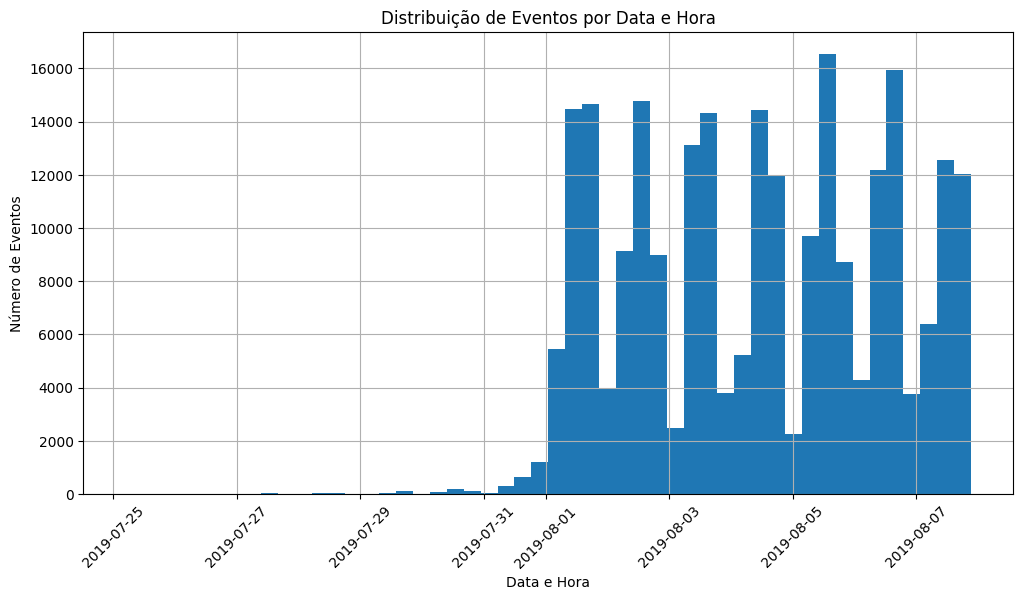

In [54]:
# Criando histograma por data e hora
df['data_hora'].hist(bins=50, figsize=(12, 6))
plt.title('Distribuição de Eventos por Data e Hora')
plt.xlabel('Data e Hora')
plt.ylabel('Número de Eventos')
plt.xticks(rotation=45)
plt.show()

#### Pela análise do gráfico anterior cheguei a conclusão que os dados passaram a ser completos a partir do dia 01/08 por isso irei descartar todos os dados anteriores.

In [55]:
# Excluindo dados incompletos

df['data'] = pd.to_datetime(df['data'])
df_wo_incomplete_datas = df[df['data'] >= '2019-08-01']

In [56]:
# Verificando o intervalo de datas após a exclusão

df_wo_incomplete_datas['data'].min(), df_wo_incomplete_datas['data'].max()

(Timestamp('2019-08-01 00:00:00'), Timestamp('2019-08-07 00:00:00'))

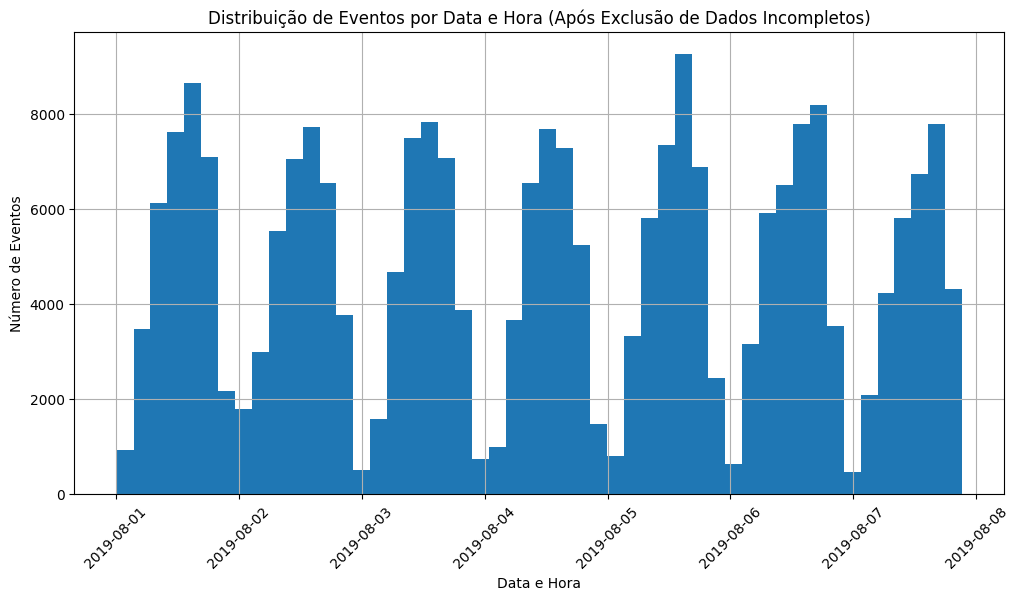

In [57]:
# Plotando novo histograma após exclusão de dados incompletos
df_wo_incomplete_datas['data_hora'].hist(bins=50, figsize=(12, 6))
plt.title('Distribuição de Eventos por Data e Hora (Após Exclusão de Dados Incompletos)')
plt.xlabel('Data e Hora')
plt.ylabel('Número de Eventos')
plt.xticks(rotation=45)
plt.show()

#### Tarefa 5

In [58]:
# Verificando dataframe após exclusão de dados incompletos
df_wo_incomplete_datas.info()

<class 'pandas.core.frame.DataFrame'>
Index: 241298 entries, 2828 to 244125
Data columns (total 6 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   event_name       241298 non-null  category      
 1   device_idhash    241298 non-null  int64         
 2   event_timestamp  241298 non-null  int64         
 3   exp_id           241298 non-null  category      
 4   data_hora        241298 non-null  datetime64[ns]
 5   data             241298 non-null  datetime64[ns]
dtypes: category(2), datetime64[ns](2), int64(2)
memory usage: 9.7 MB


#### A perda de dados foi muito pequena para ser relevante

#### Tarefa 6

In [59]:
# Verificando se todos os grupos estão presentes
df_wo_incomplete_datas['exp_id'].value_counts()

exp_id
248    84726
246    79425
247    77147
Name: count, dtype: int64

#### Passo 4

#### Tarefa 1

In [60]:
# Verificando quais eventos ocorreram, a frequência de cada um e organizando por ordem de frequência.
df_wo_incomplete_datas['event_name'].value_counts()

event_name
MainScreenAppear           117431
OffersScreenAppear          46350
CartScreenAppear            42365
PaymentScreenSuccessful     34113
Tutorial                     1039
Name: count, dtype: int64

#### Tarefa 2

In [61]:
#Verificando quantos usuários fizeram cada evento
usuarios_por_evento = df_wo_incomplete_datas.groupby('event_name')['device_idhash'].nunique().reset_index(name='num_usuarios').sort_values(by='num_usuarios', ascending=False)
print(usuarios_por_evento)

                event_name  num_usuarios
1         MainScreenAppear          7419
2       OffersScreenAppear          4593
0         CartScreenAppear          3734
3  PaymentScreenSuccessful          3539
4                 Tutorial           840


C:\Users\João\AppData\Local\Temp\ipykernel_24380\2274155787.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  usuarios_por_evento = df_wo_incomplete_datas.groupby('event_name')['device_idhash'].nunique().reset_index(name='num_usuarios').sort_values(by='num_usuarios', ascending=False)


In [62]:
# Calculando a proporção de usuarios que realizaram o evento pelo menos uma vez
total_usuarios = df_wo_incomplete_datas['device_idhash'].nunique()
usuarios_por_evento['proporcao_usuarios'] = usuarios_por_evento['num_usuarios'] / total_usuarios
print(usuarios_por_evento[['event_name', 'num_usuarios', 'proporcao_usuarios']])

                event_name  num_usuarios  proporcao_usuarios
1         MainScreenAppear          7419            0.984736
2       OffersScreenAppear          4593            0.609636
0         CartScreenAppear          3734            0.495620
3  PaymentScreenSuccessful          3539            0.469737
4                 Tutorial           840            0.111495


#### Tarefa 3

#### Pela teoria do que normalmente se segue, o caminho a se seguir é o que já é definido pela quantidade de acessos.

#### Tarefa 4

In [63]:
# Calculando a proporção de usuários de um evento que seguiram para o próximo evento
usuarios_main_screen = df_wo_incomplete_datas[df_wo_incomplete_datas['event_name'] == 'MainScreenAppear']['device_idhash'].nunique()
usuarios_offers_screen = df_wo_incomplete_datas[df_wo_incomplete_datas['event_name'] == 'OffersScreenAppear']['device_idhash'].nunique()
usuarios_cart_screen = df_wo_incomplete_datas[df_wo_incomplete_datas['event_name'] == 'CartScreenAppear']['device_idhash'].nunique()
usuarios_payment_screen = df_wo_incomplete_datas[df_wo_incomplete_datas['event_name'] == 'PaymentScreenSuccessful']['device_idhash'].nunique()
proporcao_main_to_offers = usuarios_offers_screen / usuarios_main_screen
proporcao_offers_to_cart = usuarios_cart_screen / usuarios_offers_screen
proporcao_cart_to_payment = usuarios_payment_screen / usuarios_cart_screen
print(f'Proporção de usuários que foram da MainScreen para OffersScreen: {proporcao_main_to_offers:.2%}')
print(f'Proporção de usuários que foram da OffersScreen para CartScreen: {proporcao_offers_to_cart:.2%}')
print(f'Proporção de usuários que foram da CartScreen para PaymentScreen: {proporcao_cart_to_payment:.2%}')

Proporção de usuários que foram da MainScreen para OffersScreen: 61.91%
Proporção de usuários que foram da OffersScreen para CartScreen: 81.30%
Proporção de usuários que foram da CartScreen para PaymentScreen: 94.78%


#### Tarefa 5

#### A fase que perdemos mais usuários é da MainScreen para a OffersScreen. 

#### Tarefa 6

In [64]:
# Calculando a parcela de usuarios que realizaram o caminho completo.
usuarios_que_fizeram_caminho_completo =  usuarios_payment_screen / total_usuarios
print(f'Proporção de usuários que realizaram o caminho completo: {usuarios_que_fizeram_caminho_completo:.2%}')

Proporção de usuários que realizaram o caminho completo: 46.97%


### Passo 5

#### Tarefa 1

In [65]:
# Quantos usuários há em cada grupo experimental?
usuarios_por_grupo = df_wo_incomplete_datas.groupby('exp_id')['device_idhash'].nunique().reset_index(name='num_usuarios')
print(usuarios_por_grupo)

  exp_id  num_usuarios
0    246          2484
1    247          2513
2    248          2537


C:\Users\João\AppData\Local\Temp\ipykernel_24380\3394020758.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  usuarios_por_grupo = df_wo_incomplete_datas.groupby('exp_id')['device_idhash'].nunique().reset_index(name='num_usuarios')


#### Tarefa 2

In [66]:
# Verificando possível diferença estatística entre os dois grupos de controle
grupo_a = df_wo_incomplete_datas[df_wo_incomplete_datas['exp_id'] == '246']
grupo_b = df_wo_incomplete_datas[df_wo_incomplete_datas['exp_id'] == '247']
eventos_por_usuario_a = grupo_a.groupby('device_idhash').size()
eventos_por_usuario_b = grupo_b.groupby('device_idhash').size()
t_stat, p_value = stats.ttest_ind(eventos_por_usuario_a, eventos_por_usuario_b, equal_var=False)
alpha = 0.1
print(f'T-statistic: {t_stat:.4f}, P-value: {p_value:.4f}')
if p_value < alpha:
    print("Há uma diferença estatisticamente significativa entre os dois grupos.")
else:
    print("Não há uma diferença estatisticamente significativa entre os dois grupos.")

T-statistic: 0.7402, P-value: 0.4592
Não há uma diferença estatisticamente significativa entre os dois grupos.


#### Tarefa 3

In [67]:
# Encontrando o evento mais popular.
evento_mais_popular = df_wo_incomplete_datas['event_name'].value_counts().idxmax()
print(f'O evento mais popular é: {evento_mais_popular}')

O evento mais popular é: MainScreenAppear


In [68]:
# Criando tabela analítica com linhas por evento e colunas por grupo experimental, preenchida com o número de usuários únicos que realizaram cada evento em cada grupo.
tabela_analitica = df_wo_incomplete_datas.groupby(['event_name', 'exp_id'])['device_idhash'].nunique().unstack(fill_value=0)
print(tabela_analitica)

exp_id                    246   247   248
event_name                               
CartScreenAppear         1266  1238  1230
MainScreenAppear         2450  2476  2493
OffersScreenAppear       1542  1520  1531
PaymentScreenSuccessful  1200  1158  1181
Tutorial                  278   283   279


C:\Users\João\AppData\Local\Temp\ipykernel_24380\1902090304.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tabela_analitica = df_wo_incomplete_datas.groupby(['event_name', 'exp_id'])['device_idhash'].nunique().unstack(fill_value=0)


In [69]:
# Calculando a proporção de usuários que realizaram cada evento em cada grupo experimental
proporcao_por_grupo = tabela_analitica.div(tabela_analitica.sum(axis=0), axis=1)
print(proporcao_por_grupo)

exp_id                        246       247       248
event_name                                           
CartScreenAppear         0.187945  0.185468  0.183199
MainScreenAppear         0.363717  0.370936  0.371314
OffersScreenAppear       0.228919  0.227715  0.228031
PaymentScreenSuccessful  0.178147  0.173483  0.175901
Tutorial                 0.041271  0.042397  0.041555


In [70]:
# Definindo função para efetuar teste de hipótese para cada evento entre os grupos experimentais com a tabela analítica criada.
def teste_hipotese_evento(evento):
    grupo_a = tabela_analitica.loc[evento, '246']
    grupo_b = tabela_analitica.loc[evento, '247']
    total_a = tabela_analitica['246'].sum()
    total_b = tabela_analitica['247'].sum()
    prop_a = grupo_a / total_a
    prop_b = grupo_b / total_b
    se = np.sqrt(prop_a * (1 - prop_a) / total_a + prop_b * (1 - prop_b) / total_b)
    z_score = (prop_a - prop_b) / se
    p_value = 2 * (1 - stats.norm.cdf(abs(z_score)))
    alpha = 0.1
    print(f'Evento: {evento} - Z-score: {z_score:.4f}, P-value: {p_value:.4f}')
    if p_value < alpha:
        print("Há uma diferença estatisticamente significativa entre os grupos para este evento.")
    else:
        print("Não há uma diferença estatisticamente significativa entre os grupos para este evento.")

In [71]:
# Chamando a função criada para cada evento presente na tabela analítica.
for evento in tabela_analitica.index:
    teste_hipotese_evento(evento)

Evento: CartScreenAppear - Z-score: 0.3681, P-value: 0.7128
Não há uma diferença estatisticamente significativa entre os grupos para este evento.
Evento: MainScreenAppear - Z-score: -0.8671, P-value: 0.3859
Não há uma diferença estatisticamente significativa entre os grupos para este evento.
Evento: OffersScreenAppear - Z-score: 0.1661, P-value: 0.8681
Não há uma diferença estatisticamente significativa entre os grupos para este evento.
Evento: PaymentScreenSuccessful - Z-score: 0.7095, P-value: 0.4780
Não há uma diferença estatisticamente significativa entre os grupos para este evento.
Evento: Tutorial - Z-score: -0.3257, P-value: 0.7446
Não há uma diferença estatisticamente significativa entre os grupos para este evento.


In [72]:
# Somando 246 e 247 para verificar o total de usuários que realizaram cada evento, independente do grupo experimental.
tabela_analitica['total_experimental'] = tabela_analitica['246'] + tabela_analitica['247']
print(tabela_analitica)

exp_id                    246   247   248  total_experimental
event_name                                                   
CartScreenAppear         1266  1238  1230                2504
MainScreenAppear         2450  2476  2493                4926
OffersScreenAppear       1542  1520  1531                3062
PaymentScreenSuccessful  1200  1158  1181                2358
Tutorial                  278   283   279                 561


In [74]:
def teste_hipotese_evento_grupo_teste(evento):
    grupo_a = tabela_analitica.loc[evento, 'total_experimental']
    grupo_b = tabela_analitica.loc[evento, '248']
    total_a = tabela_analitica['total_experimental'].sum()
    total_b = tabela_analitica['248'].sum()
    prop_a = grupo_a / total_a
    prop_b = grupo_b / total_b
    se = np.sqrt(prop_a * (1 - prop_a) / total_a + prop_b * (1 - prop_b) / total_b)
    z_score = (prop_a - prop_b) / se
    p_value = 2 * (1 - stats.norm.cdf(abs(z_score)))
    alpha = 0.1
    print(f'Evento: {evento} - Z-score: {z_score:.4f}, P-value: {p_value:.4f}')
    if p_value < alpha:
        print("Há uma diferença estatisticamente significativa entre os grupos para este evento.")
    else:
        print("Não há uma diferença estatisticamente significativa entre os grupos para este evento.")

In [75]:
# Chamando a função para cada evento da tabela analítica, comparando o grupo de teste (248) com a soma dos grupos de controle (246 + 247).
for evento in tabela_analitica.index:
    teste_hipotese_evento_grupo_teste(evento)

Evento: CartScreenAppear - Z-score: 0.6060, P-value: 0.5445
Não há uma diferença estatisticamente significativa entre os grupos para este evento.
Evento: MainScreenAppear - Z-score: -0.5546, P-value: 0.5791
Não há uma diferença estatisticamente significativa entre os grupos para este evento.
Evento: OffersScreenAppear - Z-score: 0.0461, P-value: 0.9632
Não há uma diferença estatisticamente significativa entre os grupos para este evento.
Evento: PaymentScreenSuccessful - Z-score: -0.0132, P-value: 0.9894
Não há uma diferença estatisticamente significativa entre os grupos para este evento.
Evento: Tutorial - Z-score: 0.0925, P-value: 0.9263
Não há uma diferença estatisticamente significativa entre os grupos para este evento.


#### Defini 0.1 que é o mais comum utilizado no mercado como um todo. Fiz 11 testes aos todo. 

#### Através de todos os testes realizados foi verificado que o grupo de teste não trazia um resultado relevante para a empresa portanto indico que os testes sejam cancelados e a maneira anterior seja mantida.